# Instalação de pacotes

In [1]:
!pip install openai scikit-learn pandas Groq kaggle


[notice] A new release of pip is available: 26.0.1 -> 26.1.1
[notice] To update, run: python.exe -m pip install --upgrade pip


# Imports

In [2]:
import pandas as pd
import numpy as np
import os

# Download da base

In [ ]:
import subprocess
import sys

subprocess.run([sys.executable, "download_data.py"], check=True)

In [3]:
df = pd.read_csv("application_train.csv")
df.head()

,SK_ID_CURR,TARGET,NAME_CONTRACT_TYPE,CODE_GENDER,FLAG_OWN_CAR,FLAG_OWN_REALTY,CNT_CHILDREN,AMT_INCOME_TOTAL,AMT_CREDIT,AMT_ANNUITY,...,FLAG_DOCUMENT_18,FLAG_DOCUMENT_19,FLAG_DOCUMENT_20,FLAG_DOCUMENT_21,AMT_REQ_CREDIT_BUREAU_HOUR,AMT_REQ_CREDIT_BUREAU_DAY,AMT_REQ_CREDIT_BUREAU_WEEK,AMT_REQ_CREDIT_BUREAU_MON,AMT_REQ_CREDIT_BUREAU_QRT,AMT_REQ_CREDIT_BUREAU_YEAR
0,100002,1,Cash loans,M,N,Y,0,202500.0,406597.5,24700.5,...,0,0,0,0,0.0,0.0,0.0,0.0,0.0,1.0
1,100003,0,Cash loans,F,N,N,0,270000.0,1293502.5,35698.5,...,0,0,0,0,0.0,0.0,0.0,0.0,0.0,0.0
2,100004,0,Revolving loans,M,Y,Y,0,67500.0,135000.0,6750.0,...,0,0,0,0,0.0,0.0,0.0,0.0,0.0,0.0
3,100006,0,Cash loans,F,N,Y,0,135000.0,312682.5,29686.5,...,0,0,0,0,NaN,NaN,NaN,NaN,NaN,NaN
4,100007,0,Cash loans,M,N,Y,0,121500.0,513000.0,21865.5,...,0,0,0,0,0.0,0.0,0.0,0.0,0.0,0.0


# Selecionar variáveis

In [4]:
base_cols = [
    "TARGET",
    "AMT_INCOME_TOTAL",
    "AMT_CREDIT",
    "AMT_ANNUITY",
    "DAYS_EMPLOYED",
    "EXT_SOURCE_1",
    "EXT_SOURCE_2",
    "EXT_SOURCE_3"
]

new_num_cols = [
    "AMT_GOODS_PRICE",
    "DAYS_BIRTH",
    "DAYS_REGISTRATION",
    "DAYS_ID_PUBLISH",
    "DAYS_LAST_PHONE_CHANGE",
    "REGION_POPULATION_RELATIVE",
    "REGION_RATING_CLIENT",
    "REGION_RATING_CLIENT_W_CITY",
    "CNT_CHILDREN",
    "CNT_FAM_MEMBERS",
    "DEF_30_CNT_SOCIAL_CIRCLE",
    "DEF_60_CNT_SOCIAL_CIRCLE",
    "OBS_30_CNT_SOCIAL_CIRCLE",
    "REG_CITY_NOT_WORK_CITY",
    "REG_CITY_NOT_LIVE_CITY",
    "LIVE_CITY_NOT_WORK_CITY",
    "FLAG_EMP_PHONE",
    "FLAG_DOCUMENT_3"
]

cat_features = [
    "NAME_CONTRACT_TYPE",
    "CODE_GENDER",
    "FLAG_OWN_CAR",
    "FLAG_OWN_REALTY",
    "NAME_INCOME_TYPE",
    "NAME_EDUCATION_TYPE",
    "NAME_FAMILY_STATUS",
    "NAME_HOUSING_TYPE",
    "OCCUPATION_TYPE",
    "NAME_TYPE_SUITE"
]

cols = list(dict.fromkeys(base_cols + new_num_cols + cat_features))

df = df[cols].copy()

# Na base Home Credit, 365243 representa um valor especial para clientes sem emprego registrado.
df["DAYS_EMPLOYED"] = df["DAYS_EMPLOYED"].replace(365243, np.nan)

df.head()

,TARGET,AMT_INCOME_TOTAL,AMT_CREDIT,AMT_ANNUITY,DAYS_EMPLOYED,EXT_SOURCE_1,EXT_SOURCE_2,EXT_SOURCE_3,AMT_GOODS_PRICE,DAYS_BIRTH,...,NAME_CONTRACT_TYPE,CODE_GENDER,FLAG_OWN_CAR,FLAG_OWN_REALTY,NAME_INCOME_TYPE,NAME_EDUCATION_TYPE,NAME_FAMILY_STATUS,NAME_HOUSING_TYPE,OCCUPATION_TYPE,NAME_TYPE_SUITE
0,1,202500.0,406597.5,24700.5,-637.0,0.083037,0.262949,0.139376,351000.0,-9461,...,Cash loans,M,N,Y,Working,Secondary / secondary special,Single / not married,House / apartment,Laborers,Unaccompanied
1,0,270000.0,1293502.5,35698.5,-1188.0,0.311267,0.622246,NaN,1129500.0,-16765,...,Cash loans,F,N,N,State servant,Higher education,Married,House / apartment,Core staff,Family
2,0,67500.0,135000.0,6750.0,-225.0,NaN,0.555912,0.729567,135000.0,-19046,...,Revolving loans,M,Y,Y,Working,Secondary / secondary special,Single / not married,House / apartment,Laborers,Unaccompanied
3,0,135000.0,312682.5,29686.5,-3039.0,NaN,0.650442,NaN,297000.0,-19005,...,Cash loans,F,N,Y,Working,Secondary / secondary special,Civil marriage,House / apartment,Laborers,Unaccompanied
4,0,121500.0,513000.0,21865.5,-3038.0,NaN,0.322738,NaN,513000.0,-19932,...,Cash loans,M,N,Y,Working,Secondary / secondary special,Single / not married,House / apartment,Core staff,Unaccompanied


# Feature Engineering

* DTI → quanto da renda está comprometida
* credit_income_ratio → tamanho do crédito vs renda

In [5]:
df["DAYS_BIRTH_YEARS"] = (-df["DAYS_BIRTH"]) / 365

for col in ["DAYS_EMPLOYED", "DAYS_REGISTRATION", "DAYS_ID_PUBLISH", "DAYS_LAST_PHONE_CHANGE"]:
    df[f"{col}_YEARS"] = (-df[col]) / 365

df["dti"] = df["AMT_ANNUITY"] / df["AMT_INCOME_TOTAL"]
df["credit_income_ratio"] = df["AMT_CREDIT"] / df["AMT_INCOME_TOTAL"]
df["annuity_credit_ratio"] = df["AMT_ANNUITY"] / df["AMT_CREDIT"]
df["goods_credit_ratio"] = df["AMT_GOODS_PRICE"] / df["AMT_CREDIT"]
df["income_per_family_member"] = df["AMT_INCOME_TOTAL"] / df["CNT_FAM_MEMBERS"].replace(0, np.nan)

df["ext_source_mean"] = df[["EXT_SOURCE_1", "EXT_SOURCE_2", "EXT_SOURCE_3"]].mean(axis=1)
df["ext_source_min"] = df[["EXT_SOURCE_1", "EXT_SOURCE_2", "EXT_SOURCE_3"]].min(axis=1)
df["ext_source_max"] = df[["EXT_SOURCE_1", "EXT_SOURCE_2", "EXT_SOURCE_3"]].max(axis=1)

# Train

In [6]:
from sklearn.compose import ColumnTransformer
from sklearn.model_selection import train_test_split
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.pipeline import Pipeline

engineered_num_cols = [
    "DAYS_BIRTH_YEARS",
    "DAYS_EMPLOYED_YEARS",
    "DAYS_REGISTRATION_YEARS",
    "DAYS_ID_PUBLISH_YEARS",
    "DAYS_LAST_PHONE_CHANGE_YEARS",
    "dti",
    "credit_income_ratio",
    "annuity_credit_ratio",
    "goods_credit_ratio",
    "income_per_family_member",
    "ext_source_mean",
    "ext_source_min",
    "ext_source_max"
]

num_features = [
    col for col in base_cols[1:] + new_num_cols + engineered_num_cols
    if col in df.columns
]

X = df[num_features + cat_features]
y = df["TARGET"]

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

numeric_lr = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", StandardScaler())
])

numeric_tree = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="median"))
])

categorical = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="most_frequent")),
    ("onehot", OneHotEncoder(handle_unknown="ignore"))
])

preprocess_lr = ColumnTransformer(transformers=[
    ("num", numeric_lr, num_features),
    ("cat", categorical, cat_features)
])

preprocess_tree = ColumnTransformer(transformers=[
    ("num", numeric_tree, num_features),
    ("cat", categorical, cat_features)
])

print(f"Variáveis numéricas: {len(num_features)}")
print(f"Variáveis categóricas: {len(cat_features)}")

Variáveis numéricas: 38
Variáveis categóricas: 10


In [7]:
# Logistic Regression
from sklearn.linear_model import LogisticRegression

modelLR = Pipeline(steps=[
    ("preprocess", preprocess_lr),
    ("model", LogisticRegression(max_iter=1000, class_weight="balanced", random_state=42))
])

modelLR.fit(X_train, y_train)

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators ` for more details.","[('preprocess', ...), ('model', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing `.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('num', ...), ('cat', ...)]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder='passthrough'``, all remaining columns thatwere not specified in `transformers`, but present in the data passedto `fit` will be automatically passed through. This subset of columnsis concatenated with the output of the transformers. For dataframes,extra columns not seen during `fit` will be excluded from the outputof `transform`.By setting ``remainder`` to be an estimator, the remainingnon-specified columns will use the ``remainder`` estimator. Theestimator must support :term:`fit` and :term:`transform`.Note that using this feature requires that the DataFrame columnsinput at :term:`fit` and :term:`transform` have identical order.",'drop'
,"sparse_threshold sparse_threshold: float, default=0.3If the output of the different transformers cont

In [8]:
# Random Forest
from sklearn.ensemble import RandomForestClassifier

modelRF = Pipeline(steps=[
    ("preprocess", preprocess_tree),
    ("model", RandomForestClassifier(
        n_estimators=150,
        class_weight="balanced",
        random_state=42,
        n_jobs=-1,
        max_depth=12,
        min_samples_leaf=50
    ))
])

modelRF.fit(X_train, y_train)

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators ` for more details.","[('preprocess', ...), ('model', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing `.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('num', ...), ('cat', ...)]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder='passthrough'``, all remaining columns thatwere not specified in `transformers`, but present in the data passedto `fit` will be automatically passed through. This subset of columnsis concatenated with the output of the transformers. For dataframes,extra columns not seen during `fit` will be excluded from the outputof `transform`.By setting ``remainder`` to be an estimator, the remainingnon-specified columns will use the ``remainder`` estimator. Theestimator must support :term:`fit` and :term:`transform`.Note that using this feature requires that the DataFrame columnsinput at :term:`fit` and :term:`transform` have identical order.",'drop'
,"sparse_threshold sparse_threshold: float, default=0.3If the output of the different transformers cont

# Avaliação dos modelos

Como a base é desbalanceada, a AUC é importante, mas não basta sozinha. Também vamos olhar precisão, recall e matriz de confusão para entender melhor o comportamento do modelo na classe de inadimplência.

Taxa de inadimplência no teste: 8.07%
Regressão Logística - AUC:  0.7479364429994004
Random Forest - AUC:  0.752754940246945

Relatório de classificação - Random Forest
              precision    recall  f1-score   support

           0      0.956     0.756     0.844     56538
           1      0.179     0.604     0.276      4965

    accuracy                          0.744     61503
   macro avg      0.567     0.680     0.560     61503
weighted avg      0.893     0.744     0.798     61503

Matriz de confusão - Random Forest
[[42729 13809]
 [ 1964  3001]]


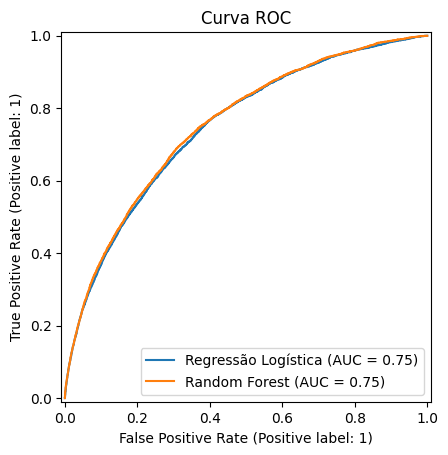

In [9]:
from sklearn.metrics import (
    classification_report,
    confusion_matrix,
    roc_auc_score,
    RocCurveDisplay
)
import matplotlib.pyplot as plt

predsLR = modelLR.predict_proba(X_test)[:, 1]
predsRF = modelRF.predict_proba(X_test)[:, 1]

print(f"Taxa de inadimplência no teste: {y_test.mean():.2%}")
print('Regressão Logística - AUC: ', roc_auc_score(y_test, predsLR))
print('Random Forest - AUC: ', roc_auc_score(y_test, predsRF))

modelo_escolhido = modelRF
preds_modelo = predsRF
y_pred = (preds_modelo >= 0.5).astype(int)

print("\nRelatório de classificação - Random Forest")
print(classification_report(y_test, y_pred, digits=3))

print("Matriz de confusão - Random Forest")
print(confusion_matrix(y_test, y_pred))

RocCurveDisplay.from_predictions(y_test, predsLR, name="Regressão Logística")
RocCurveDisplay.from_predictions(y_test, predsRF, name="Random Forest", ax=plt.gca())
plt.title("Curva ROC")
plt.show()

# Explicabilidade dos modelos

Nesta etapa, vamos olhar quais variáveis mais pesam nos modelos. Isso ajuda a transformar a previsão em uma análise de crédito mais interpretável.

,feature,coeficiente_regressao_logistica,impacto_absoluto
7,num__AMT_GOODS_PRICE,-0.582757,0.582757
1,num__AMT_CREDIT,0.382986,0.382986
6,num__EXT_SOURCE_3,-0.342689,0.342689
81,cat__OCCUPATION_TYPE_Low-skill Laborers,0.333052,0.333052
55,cat__NAME_EDUCATION_TYPE_Academic degree,-0.298029,0.298029
69,cat__NAME_HOUSING_TYPE_Office apartment,-0.273974,0.273974
58,cat__NAME_EDUCATION_TYPE_Lower secondary,0.267427,0.267427
35,num__ext_source_mean,-0.259402,0.259402
50,cat__NAME_INCOME_TYPE_Pensioner,-0.246614,0.246614
79,cat__OCCUPATION_TYPE_IT staff,-0.243242,0.243242


,feature,importancia_random_forest
35,num__ext_source_mean,0.160400
36,num__ext_source_min,0.118678
37,num__ext_source_max,0.111985
6,num__EXT_SOURCE_3,0.080954
5,num__EXT_SOURCE_2,0.065642
4,num__EXT_SOURCE_1,0.029844
33,num__goods_credit_ratio,0.028475
32,num__annuity_credit_ratio,0.025572
3,num__DAYS_EMPLOYED,0.023943
8,num__DAYS_BIRTH,0.023752


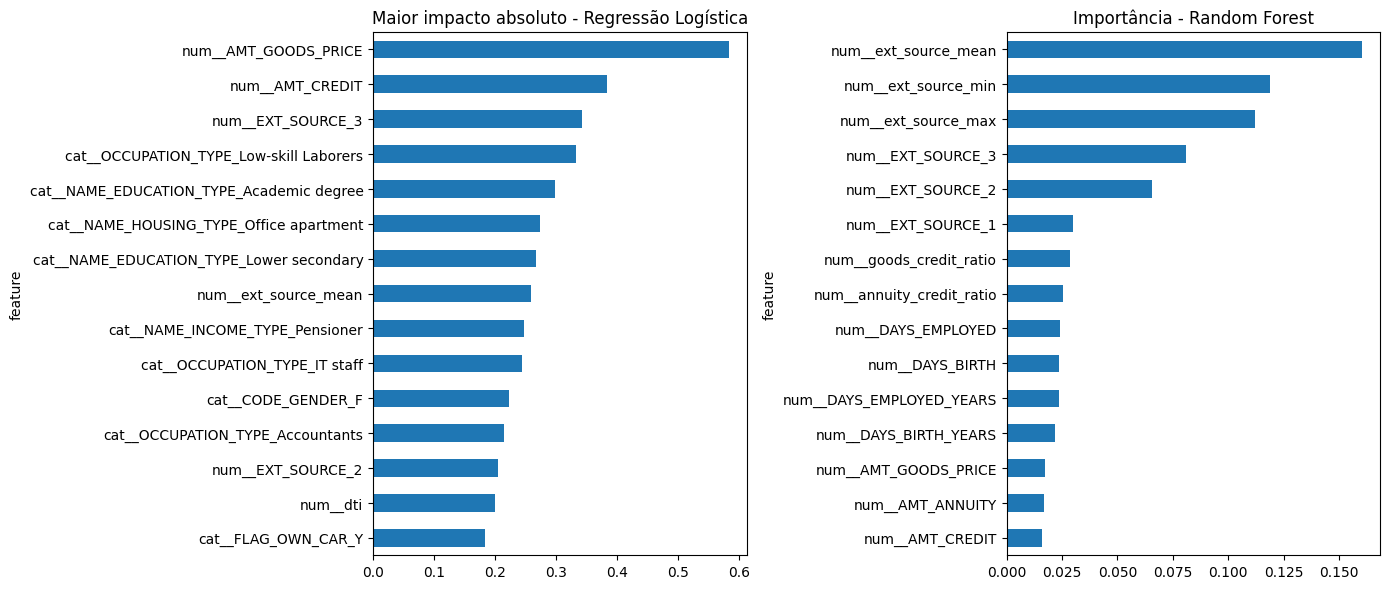

In [10]:
from IPython.display import display

feature_names_lr = modelLR.named_steps["preprocess"].get_feature_names_out()
feature_names_rf = modelRF.named_steps["preprocess"].get_feature_names_out()

coeficientes_lr = pd.DataFrame({
    "feature": feature_names_lr,
    "coeficiente_regressao_logistica": modelLR.named_steps["model"].coef_[0]
})
coeficientes_lr["impacto_absoluto"] = coeficientes_lr["coeficiente_regressao_logistica"].abs()
coeficientes_lr = coeficientes_lr.sort_values("impacto_absoluto", ascending=False)

importancias_rf = pd.DataFrame({
    "feature": feature_names_rf,
    "importancia_random_forest": modelRF.named_steps["model"].feature_importances_
}).sort_values("importancia_random_forest", ascending=False)

principais_fatores_modelo = importancias_rf.head(8)["feature"].tolist()

display(coeficientes_lr.head(20))
display(importancias_rf.head(20))

fig, axes = plt.subplots(1, 2, figsize=(14, 6))

coeficientes_lr.head(15).sort_values("impacto_absoluto").plot.barh(
    x="feature",
    y="impacto_absoluto",
    ax=axes[0],
    legend=False,
    title="Maior impacto absoluto - Regressão Logística"
)

importancias_rf.head(15).sort_values("importancia_random_forest").plot.barh(
    x="feature",
    y="importancia_random_forest",
    ax=axes[1],
    legend=False,
    title="Importância - Random Forest"
)

plt.tight_layout()
plt.show()

# Teste Cliente Real

In [11]:
def classificar_risco(prob):
    if prob < 0.10:
        return "Baixo risco"
    if prob < 0.20:
        return "Risco moderado"
    return "Alto risco"

cliente = X_test.iloc[[0]]
prob_default = modelo_escolhido.predict_proba(cliente)[0][1]
risco = classificar_risco(prob_default)

print(f"Probabilidade de inadimplência: {prob_default:.2%}")
print(f"Classificação: {risco}")
cliente

Probabilidade de inadimplência: 42.54%
Classificação: Alto risco


,AMT_INCOME_TOTAL,AMT_CREDIT,AMT_ANNUITY,DAYS_EMPLOYED,EXT_SOURCE_1,EXT_SOURCE_2,EXT_SOURCE_3,AMT_GOODS_PRICE,DAYS_BIRTH,DAYS_REGISTRATION,...,NAME_CONTRACT_TYPE,CODE_GENDER,FLAG_OWN_CAR,FLAG_OWN_REALTY,NAME_INCOME_TYPE,NAME_EDUCATION_TYPE,NAME_FAMILY_STATUS,NAME_HOUSING_TYPE,OCCUPATION_TYPE,NAME_TYPE_SUITE
256571,157500.0,770292.0,30676.5,-105.0,NaN,0.594327,0.427657,688500.0,-13506,-2876.0,...,Cash loans,M,Y,Y,Working,Higher education,Married,House / apartment,Laborers,Family


In [12]:
def criar_prompt(cliente, prob, risco):
    dados_cliente = cliente.to_dict(orient="records")[0]
    return f"""
Você é um analista de crédito de um grande banco.

Dados do cliente:
{dados_cliente}

Probabilidade estimada de inadimplência: {prob:.2%}
Classificação preliminar do modelo: {risco}
Variáveis mais relevantes para o modelo: {principais_fatores_modelo}

Considere boas práticas de crédito, mas trate o modelo como apoio à decisão, não como decisão automática.

Responda:
- Classificação de risco
- Principais fatores observados nos dados
- Recomendação
- Justificativa profissional
- Cuidados ou informações adicionais que o banco deveria verificar
"""

In [13]:
import os
from getpass import getpass
from groq import Groq


def obter_groq_api_key():
    api_key = os.environ.get("GROQ_API_KEY")

    if not api_key:
        try:
            from google.colab import userdata
            api_key = userdata.get("API_Key_GROQ")
        except Exception:
            api_key = None

    if not api_key:
        api_key = getpass("Cole sua GROQ_API_KEY: ").strip()

    if not api_key:
        raise ValueError("GROQ_API_KEY não informada. Configure a chave da Groq para gerar a análise textual.")

    os.environ["GROQ_API_KEY"] = api_key
    return api_key


client = Groq(api_key=obter_groq_api_key())

prompt = criar_prompt(cliente, prob_default, risco)

try:
    response = client.chat.completions.create(
        messages=[
            {"role": "system", "content": "Você é um especialista em risco de crédito."},
            {"role": "user", "content": prompt}
        ],
        model="llama-3.3-70b-versatile",
        temperature=0.2
    )

    analise = response.choices[0].message.content
    print(analise)
except Exception as erro:
    print("Não foi possível gerar a análise com a Groq.")
    print(f"Tipo do erro: {type(erro).__name__}")
    print(f"Detalhe: {erro}")
    print("Verifique se a chave GROQ_API_KEY está correta e se o modelo configurado está disponível na sua conta.")

**Classificação de Risco:**
Com base nos dados fornecidos e considerando as boas práticas de crédito, classifico o risco deste cliente como **Alto Risco**. Essa classificação está alinhada com a estimativa do modelo, que aponta uma probabilidade de inadimplência de 42,54%.

**Principais Fatores Observados nos Dados:**
Os principais fatores que contribuem para essa classificação incluem:
- **Relação entre a renda e o crédito (credit_income_ratio)**: O valor de 4,89 indica que o crédito solicitado é significativamente alto em relação à renda do cliente, o que pode dificultar o pagamento.
- **Relação entre a anuidade e o crédito (annuity_credit_ratio)**: Embora o valor de 0,0398 seja relativamente baixo, ele ainda é um indicador de que o cliente pode ter dificuldades em pagar a anuidade em relação ao crédito total.
- **Relação entre o bem e o crédito (goods_credit_ratio)**: O valor de 0,8938 sugere que o crédito é quase equivalente ao valor do bem, o que pode ser um risco se o cliente não